In [1]:

import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, mean_absolute_error


# Adjust display settings for wider output
pd.set_option('display.width', 300)  # Increase the display width
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_rows', 10)  # Limit rows displayed for clarity


df = pd.read_csv("/Users/olaoluwatunmise/Germany-Energy-Price-Forecast/PowerCast-Datasets/Merged-Data/enhanced_dataset.csv")

df.head()



,timestamp,energy_price,net_export,total_grid_load,residual_load,hydro_pumped_storage,biomass,hydropower,wind_offshore,wind_onshore,photovoltaics,other_renewable,lignite,hard_coal,fossil_gas,other_conventional,hour_of_day,day_of_week,is_weekend,month_of_year,season,renewable_ratio,fossil_ratio,wind_total,solar_wind_ratio,grid_balance,conventional_vs_renewable,rolling_mean_24h,rolling_std_24h,change_in_load_1h,change_in_wind_1h,change_in_fossil_1h,lag_wind_1h,lag_wind_24h,lag_demand_1h,lag_demand_24h,lead_demand_1h,lead_demand_24h,wind_solar_interaction,hydro_fossil_interaction,renewable_demand_ratio,seasonality,spike_indicator,price_spike_tool,rolling_mean_price_24h,price_spike
0,2023-01-01 00:00:00,-5.17,12001.75,38346.00,6575.00,1101.000,4014.25,1275.25,3059.25,28710.50,1.25,129.50,3859.25,2067.50,1817.75,1228.75,0,6,1,1,0,0.831912,0.234007,31769.75,0.000039,26344.25,0.208241,38346.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37777.25,36789.75,39712.1875,298.418011,0.000022,1,0,False,NaN,False
1,2023-01-01 01:00:00,-1.07,14244.25,37777.25,4885.25,1035.125,3993.25,1226.50,3586.00,29305.00,1.00,129.00,3866.50,2052.00,1663.25,1218.25,1,6,1,1,0,0.874098,0.232944,32891.00,0.000030,23533.00,0.198264,38061.625000,402.166982,-568.75,1121.25,-0.001063,31769.75,NaN,38346.00,NaN,36939.75,35423.75,32891.0000,285.706344,0.000023,1,0,False,NaN,False
2,2023-01-01 02:00:00,-1.47,13897.50,36939.75,3830.25,1595.875,3967.25,1222.50,3842.25,29266.00,1.25,129.00,3860.25,2034.25,1666.75,1211.50,2,6,1,1,0,0.899803,0.237488,33108.25,0.000038,23042.25,0.196763,37687.666667,707.392144,-837.50,217.25,0.004544,32891.00,NaN,37777.25,NaN,35932.50,35284.25,41385.3125,290.329168,0.000024,1,0,False,NaN,False
3,2023-01-01 03:00:00,-5.08,12277.25,35932.50,5459.75,1900.125,3973.00,1223.25,3463.25,27008.50,1.00,129.00,3864.75,2037.00,1659.50,1211.75,3,6,1,1,0,0.851645,0.244152,30471.75,0.000033,23655.25,0.211220,37248.875000,1050.597419,-1007.25,-2636.50,0.006664,33108.25,NaN,36939.75,NaN,35486.25,36058.50,30471.7500,298.659215,0.000024,1,0,False,NaN,False
4,2023-01-01 04:00:00,-4.49,12179.00,35486.25,5583.75,1994.500,3996.50,1244.00,3462.25,26438.75,1.50,128.25,3841.00,2040.25,1644.50,1214.25,4,6,1,1,0,0.846264,0.246293,29901.00,0.000050,23307.25,0.213368,36896.350000,1203.821241,-446.25,-570.75,0.002140,30471.75,NaN,35932.50,NaN,35647.25,37796.00,44851.5000,306.387967,0.000024,1,0,False,NaN,False


In [2]:
# Check for missing values
print(df.isnull().sum())

timestamp                  0
energy_price               0
net_export                 0
total_grid_load            0
residual_load              0
                          ..
seasonality                0
spike_indicator            0
price_spike_tool           0
rolling_mean_price_24h    23
price_spike                0
Length: 46, dtype: int64


In [3]:
df.dtypes

timestamp                  object
energy_price              float64
net_export                float64
total_grid_load           float64
residual_load             float64
                           ...   
seasonality                 int64
spike_indicator             int64
price_spike_tool             bool
rolling_mean_price_24h    float64
price_spike                  bool
Length: 46, dtype: object

In [4]:
# Convert timestamp to a datetime data type
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [5]:
df.dtypes

timestamp                 datetime64[ns]
energy_price                     float64
net_export                       float64
total_grid_load                  float64
residual_load                    float64
                               ...      
seasonality                        int64
spike_indicator                    int64
price_spike_tool                    bool
rolling_mean_price_24h           float64
price_spike                         bool
Length: 46, dtype: object

In [6]:
df["price_spike"] = df["price_spike"].astype(int)
df["price_spike_tool"] = df["price_spike_tool"].astype(int)
#df["seasonality"] = df["seasonality"].astype(int)

In [7]:
df.fillna(df.mean(), inplace=True)
#df.fillna(df.interpolate(), inplace=True)
print(df.isnull().sum().to_list())

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [8]:
df.describe()
df.head()

,timestamp,energy_price,net_export,total_grid_load,residual_load,hydro_pumped_storage,biomass,hydropower,wind_offshore,wind_onshore,photovoltaics,other_renewable,lignite,hard_coal,fossil_gas,other_conventional,hour_of_day,day_of_week,is_weekend,month_of_year,season,renewable_ratio,fossil_ratio,wind_total,solar_wind_ratio,grid_balance,conventional_vs_renewable,rolling_mean_24h,rolling_std_24h,change_in_load_1h,change_in_wind_1h,change_in_fossil_1h,lag_wind_1h,lag_wind_24h,lag_demand_1h,lag_demand_24h,lead_demand_1h,lead_demand_24h,wind_solar_interaction,hydro_fossil_interaction,renewable_demand_ratio,seasonality,spike_indicator,price_spike_tool,rolling_mean_price_24h,price_spike
0,2023-01-01 00:00:00,-5.17,12001.75,38346.00,6575.00,1101.000,4014.25,1275.25,3059.25,28710.50,1.25,129.50,3859.25,2067.50,1817.75,1228.75,0,6,1,1,0,0.831912,0.234007,31769.75,0.000039,26344.25,0.208241,38346.000000,6893.089210,0.53709,-0.964471,0.000011,16044.582091,16049.221193,53095.774705,53090.740976,37777.25,36789.75,39712.1875,298.418011,0.000022,1,0,0,89.528227,0
1,2023-01-01 01:00:00,-1.07,14244.25,37777.25,4885.25,1035.125,3993.25,1226.50,3586.00,29305.00,1.00,129.00,3866.50,2052.00,1663.25,1218.25,1,6,1,1,0,0.874098,0.232944,32891.00,0.000030,23533.00,0.198264,38061.625000,402.166982,-568.75000,1121.250000,-0.001063,31769.750000,16049.221193,38346.000000,53090.740976,36939.75,35423.75,32891.0000,285.706344,0.000023,1,0,0,89.528227,0
2,2023-01-01 02:00:00,-1.47,13897.50,36939.75,3830.25,1595.875,3967.25,1222.50,3842.25,29266.00,1.25,129.00,3860.25,2034.25,1666.75,1211.50,2,6,1,1,0,0.899803,0.237488,33108.25,0.000038,23042.25,0.196763,37687.666667,707.392144,-837.50000,217.250000,0.004544,32891.000000,16049.221193,37777.250000,53090.740976,35932.50,35284.25,41385.3125,290.329168,0.000024,1,0,0,89.528227,0
3,2023-01-01 03:00:00,-5.08,12277.25,35932.50,5459.75,1900.125,3973.00,1223.25,3463.25,27008.50,1.00,129.00,3864.75,2037.00,1659.50,1211.75,3,6,1,1,0,0.851645,0.244152,30471.75,0.000033,23655.25,0.211220,37248.875000,1050.597419,-1007.25000,-2636.500000,0.006664,33108.250000,16049.221193,36939.750000,53090.740976,35486.25,36058.50,30471.7500,298.659215,0.000024,1,0,0,89.528227,0
4,2023-01-01 04:00:00,-4.49,12179.00,35486.25,5583.75,1994.500,3996.50,1244.00,3462.25,26438.75,1.50,128.25,3841.00,2040.25,1644.50,1214.25,4,6,1,1,0,0.846264,0.246293,29901.00,0.000050,23307.25,0.213368,36896.350000,1203.821241,-446.25000,-570.750000,0.002140,30471.750000,16049.221193,35932.500000,53090.740976,35647.25,37796.00,44851.5000,306.387967,0.000024,1,0,0,89.528227,0


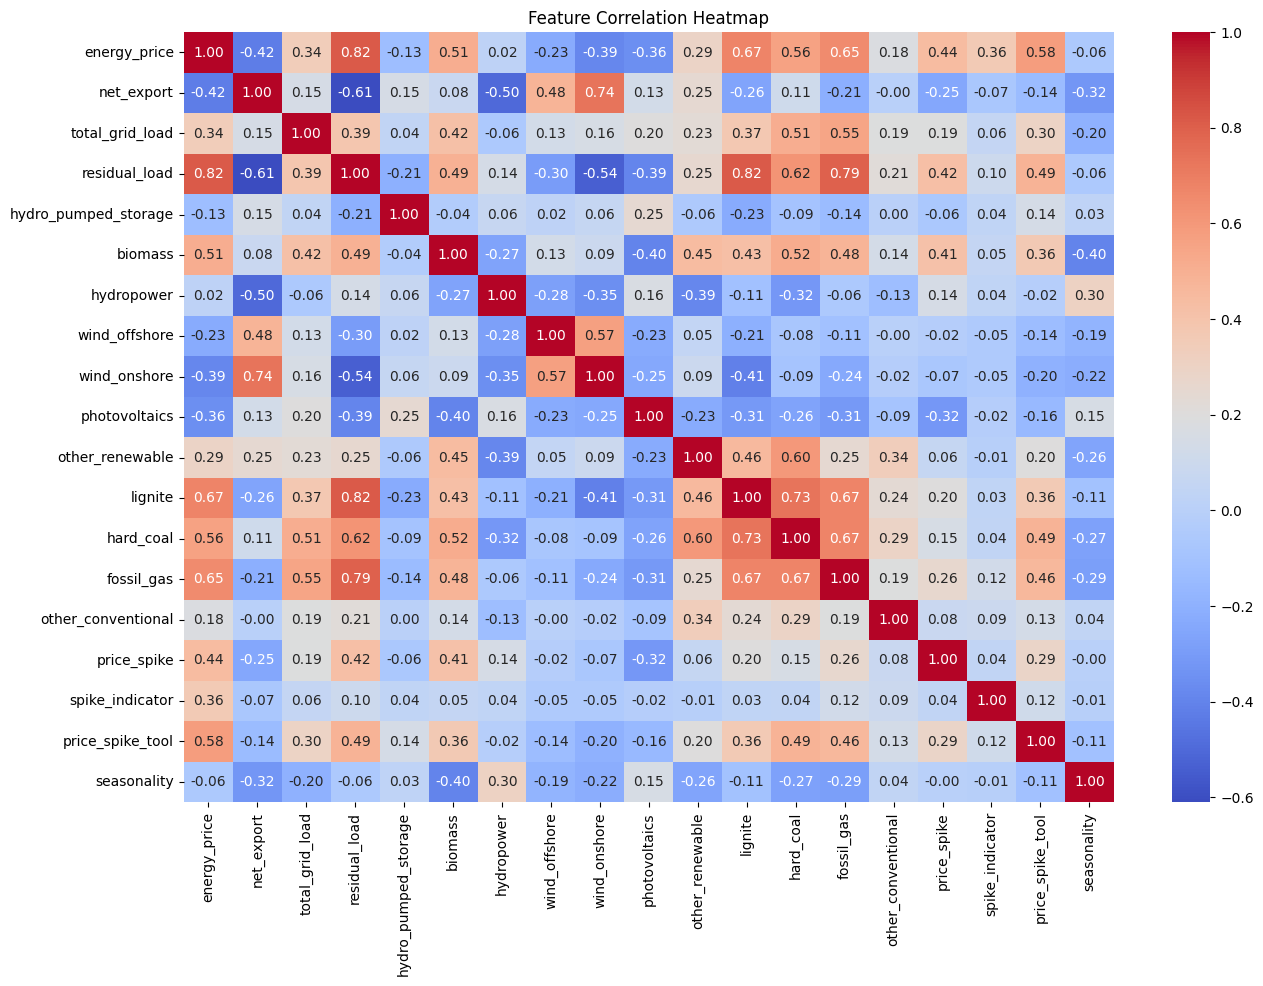

In [9]:
columns= df[[ "energy_price", "net_export", "total_grid_load", "residual_load", 
    "hydro_pumped_storage", "biomass", "hydropower", "wind_offshore", "wind_onshore", 
    "photovoltaics", "other_renewable", "lignite", "hard_coal", "fossil_gas", 
    "other_conventional", "price_spike", "spike_indicator", "price_spike_tool", "seasonality"]]

plt.figure(figsize=(15,10))
sns.heatmap(columns.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


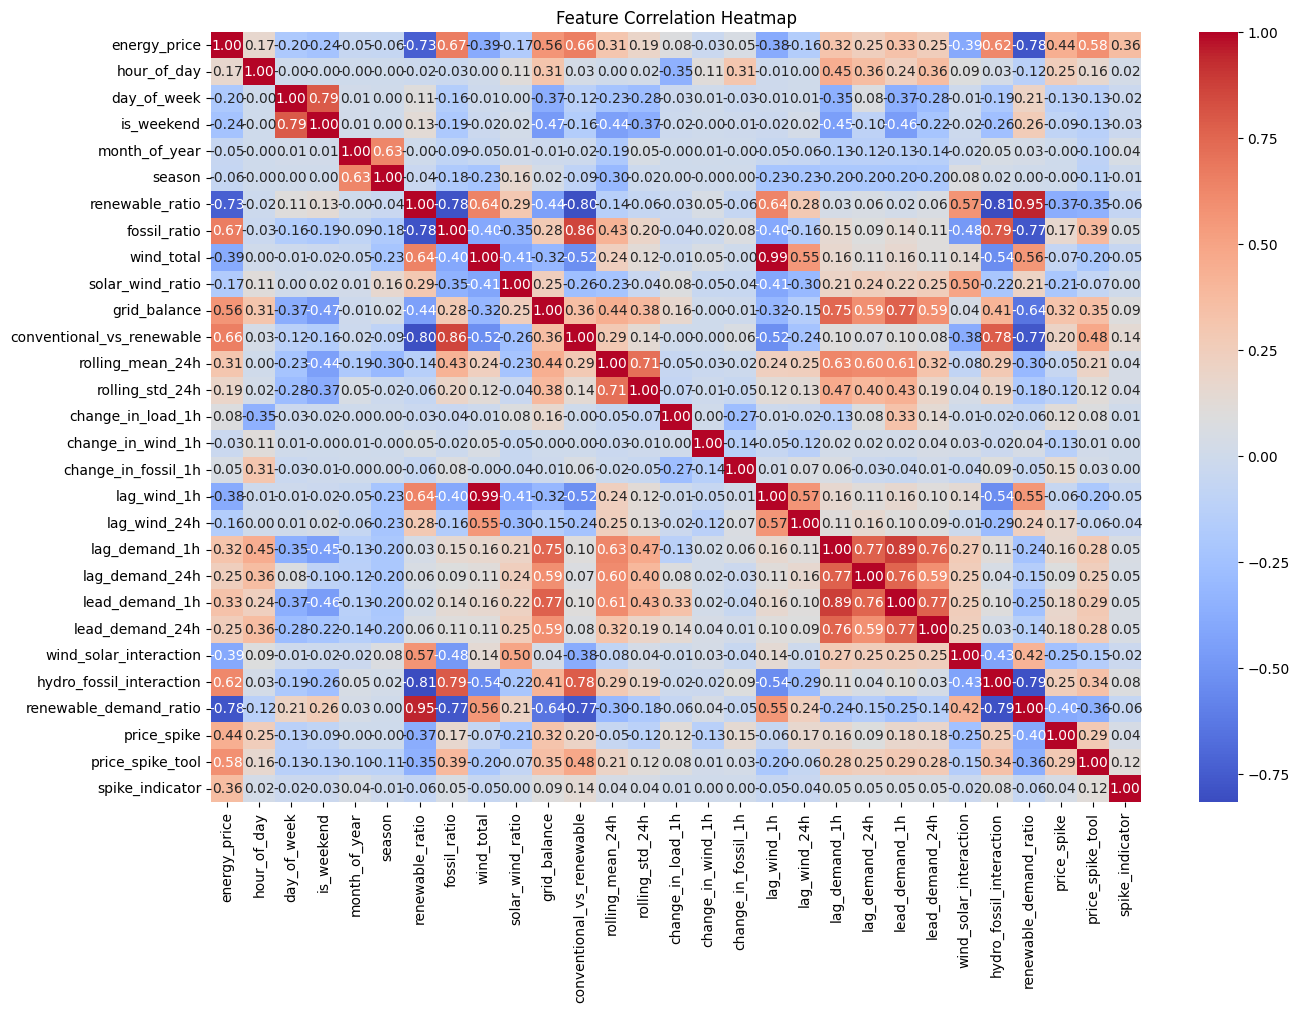

In [10]:
feature_engineer = df[[
      "energy_price", "hour_of_day", "day_of_week", "is_weekend", "month_of_year", 
    "season", "renewable_ratio", "fossil_ratio", "wind_total", "solar_wind_ratio", 
    "grid_balance", "conventional_vs_renewable", "rolling_mean_24h", "rolling_std_24h", 
    "change_in_load_1h", "change_in_wind_1h", "change_in_fossil_1h", "lag_wind_1h", 
    "lag_wind_24h", "lag_demand_1h", "lag_demand_24h", "lead_demand_1h", "lead_demand_24h", 
    "wind_solar_interaction", "hydro_fossil_interaction", "renewable_demand_ratio","price_spike", "price_spike_tool", 
    "spike_indicator"
]]

# df_columns = [f"df['{col}']" for col in columns]
# print(df_columns)

plt.figure(figsize=(15,10))
sns.heatmap(feature_engineer.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


In [11]:
feature_engineer.isna().sum().to_list()

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0]

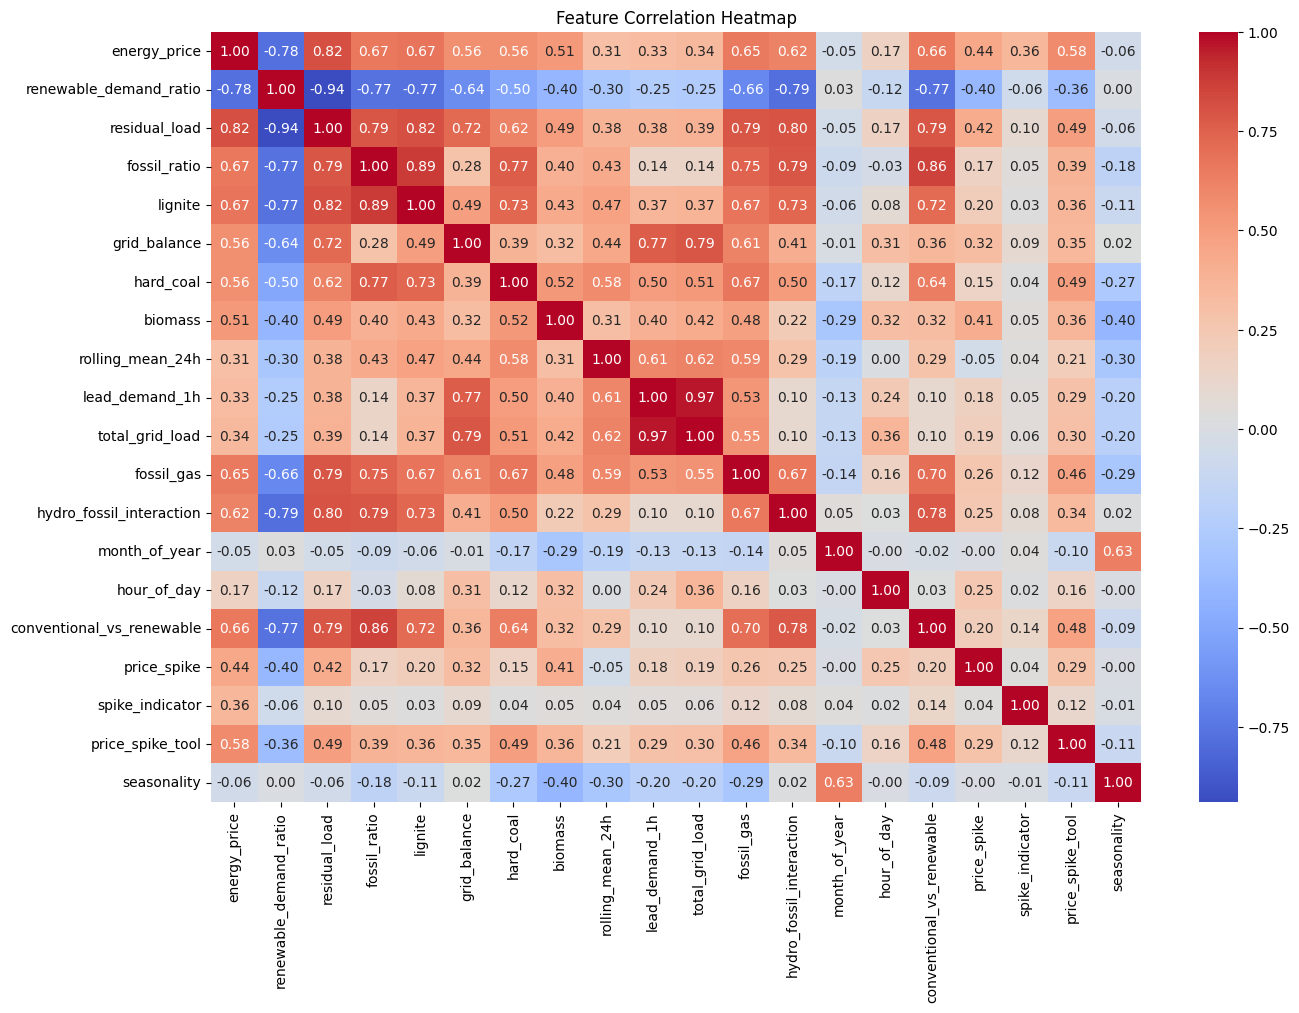

In [12]:
"""These features capture the core dynamics 
of energy prices: the balance between supply 
(renewables vs. fossil fuels) and demand 
(residual_load, total_grid_load), 
as well as temporal trends (lag_demand_1h).
"""

key_features = df[['energy_price','renewable_demand_ratio','residual_load', 'fossil_ratio', 
                   'lignite', 'grid_balance', 'hard_coal', 'biomass',
                   'rolling_mean_24h','lead_demand_1h','total_grid_load',
                   'fossil_gas','hydro_fossil_interaction','month_of_year', 'hour_of_day',
                   'conventional_vs_renewable', 'price_spike','spike_indicator', 'price_spike_tool','seasonality'
                   ]]

plt.figure(figsize=(15,10))
sns.heatmap(key_features.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

### Splitting the Data (Time-Based Split)

In [13]:
selected_features = [
    "hour_of_day", "day_of_week", "is_weekend", "month_of_year", 
    "season", "renewable_ratio", "fossil_ratio", "wind_total", "solar_wind_ratio", 
    "grid_balance", "conventional_vs_renewable", "rolling_mean_24h", "rolling_std_24h", 
    "change_in_load_1h", "change_in_wind_1h", "change_in_fossil_1h", "lag_wind_1h", 
    "lag_wind_24h", "lag_demand_1h", "lag_demand_24h", "lead_demand_1h", "lead_demand_24h", 
    "wind_solar_interaction", "hydro_fossil_interaction", "renewable_demand_ratio","price_spike",
    "spike_indicator", "price_spike_tool", "seasonality"
]

# # Features (X) and Target (y)
X = df[selected_features]
y = df['energy_price']

# # Time-based train-test split (80% Train, 20% test)
# """Since this is time-series data, I avoid random splits.
#  I use a temporal split (e.g., first 80% for training, 
#  last 20% for testing)"""

# split_idx = int(0.8 * len(df))
# X_train , X_test = X.iloc[:split_idx], X.iloc[split_idx:]
# y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
# # Proceed with train-test split
# #X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# # Verify shapes
# print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

## Time-Series Cross-Validation

In [14]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)  # Example: 5 splits with expanding window
for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    # Train/evaluate model here

# Build and Evaluate Models

I’ll train three models—XGBoost, Random Forest, and Gradient Boosting—and compare their performance using RMSE (Root Mean Squared Error) and MAE (Mean Absolute Error).



### XGBoost

XGBoost Performance:
RMSE: 28.00
MAE: 16.41
Train R^2: 0.9275, Test R^2: 0.8146


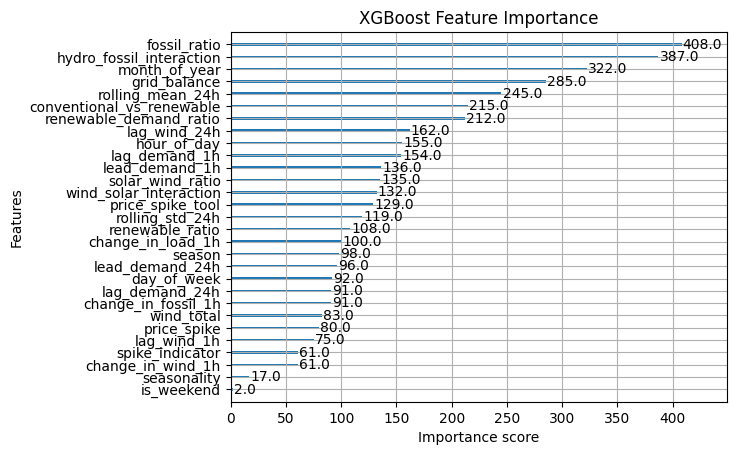

In [15]:
# Initialize and Train XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators = 300,
    learning_rate = 0.05,
    max_depth = 4,
    min_child_weight=3,  # Increase to reduce overfitting
    subsample=0.8,       # Use 80% of data per tree
    colsample_bytree=0.8,  # Use 80% of features per tree
    reg_lambda =1,
    reg_alpha=0.5,
    random_state = 42
)


xgb_model.fit(X_train, y_train)


# Predict
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = root_mean_squared_error(y_test, y_pred_xgb)

print("XGBoost Performance:")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"MAE: {mae_xgb:.2f}")

# Evaluate
train_score = xgb_model.score(X_train, y_train)
test_score = xgb_model.score(X_test, y_test)
print(f"Train R^2: {train_score:.4f}, Test R^2: {test_score:.4f}")

# Feature importance
xgb.plot_importance(xgb_model)
plt.title("XGBoost Feature Importance")
plt.show()

### Random Forest

Random Forest Performance:
RMSE: 27.20
MAE: 16.93
Train R^2: 0.9455, Test R^2: 0.8250


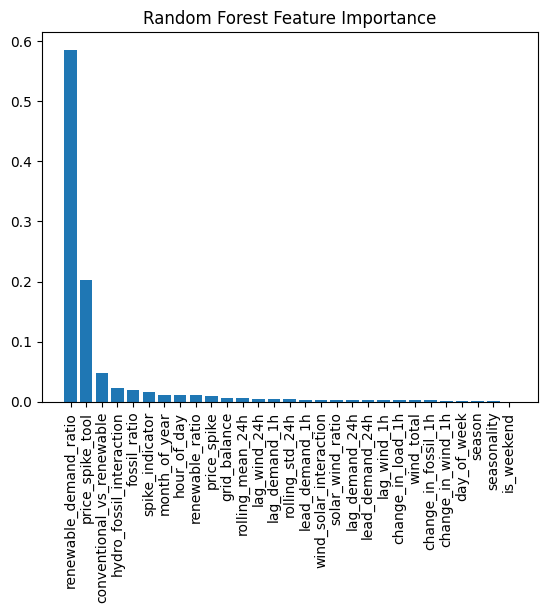

Random Forest - MAE: 16.93, RMSE: 27.20


In [16]:
# Train Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100, 
    max_depth=10, 
    random_state=42
    )

rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluate
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = root_mean_squared_error(y_test, y_pred_rf)
print("Random Forest Performance:")
print(f"RMSE: {rmse_rf:.2f}")
print(f"MAE: {mae_rf:.2f}")

# Evaluate
train_score_r = rf_model.score(X_train, y_train)
test_score_r = rf_model.score(X_test, y_test)
print(f"Train R^2: {train_score_r:.4f}, Test R^2: {test_score_r:.4f}")

# Feature importance
importances = rf_model.feature_importances_
feature_importance_rf = pd.Series(importances, index=selected_features).sort_values(ascending=False)
plt.bar(feature_importance_rf.index, feature_importance_rf)
plt.xticks(rotation=90)
plt.title("Random Forest Feature Importance")
plt.show()
print(f"Random Forest - MAE: {mae_rf:.2f}, RMSE: {rmse_rf:.2f}")


### Gradient Boosting 

Gradient Boosting Performance:
RMSE: 28.43
MAE: 16.57
Train R^2: 0.9421, Test R^2: 0.8088


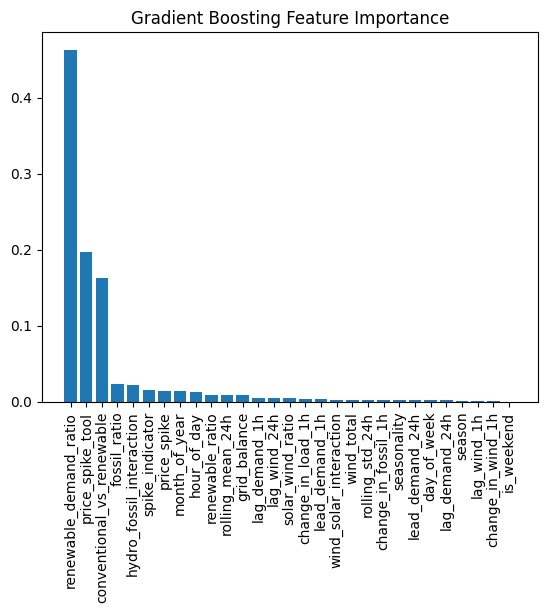

In [17]:
# Initialize and train Gradient Boosting
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
gb_model.fit(X_train, y_train)

# Predict
y_pred_gb = gb_model.predict(X_test)

# Evaluate
rmse_gb = root_mean_squared_error(y_test, y_pred_gb)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
print("Gradient Boosting Performance:")
print(f"RMSE: {rmse_gb:.2f}")
print(f"MAE: {mae_gb:.2f}")

# Evaluate
train_score_g = gb_model.score(X_train, y_train)
test_score_g = gb_model.score(X_test, y_test)
print(f"Train R^2: {train_score_g:.4f}, Test R^2: {test_score_g:.4f}")

# Feature importance
importances = gb_model.feature_importances_
feature_importance_gb = pd.Series(importances, index=selected_features).sort_values(ascending=False)
plt.bar(feature_importance_gb.index, feature_importance_gb)
plt.xticks(rotation=90)
plt.title("Gradient Boosting Feature Importance")
plt.show()

## Model Performance Comparison


Model Performance Summary:
               Model       RMSE        MAE
0            XGBoost  27.997419  16.411746
1      Random Forest  27.203608  16.931130
2  Gradient Boosting  28.432217  16.568449


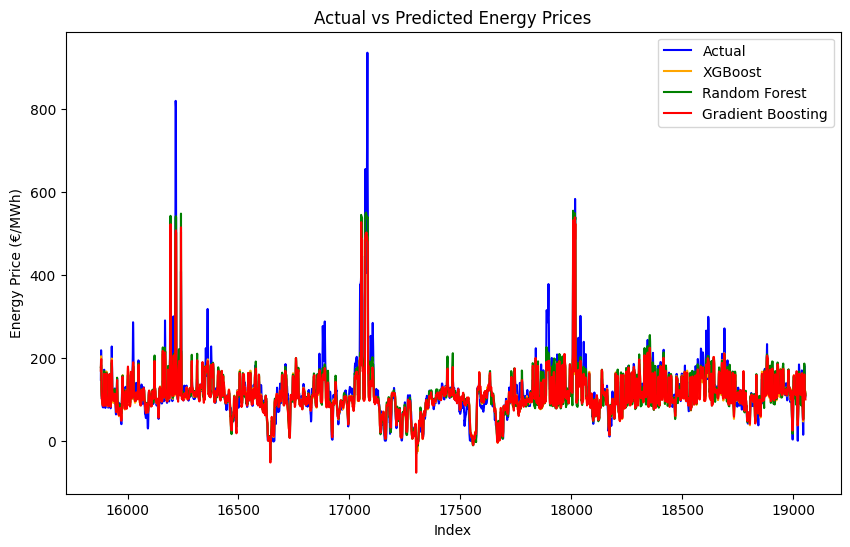

In [18]:
# Performance summary
performance = pd.DataFrame({
    'Model': ['XGBoost', 'Random Forest', 'Gradient Boosting'],
    'RMSE': [rmse_xgb, rmse_rf, rmse_gb],
    'MAE': [mae_xgb, mae_rf, mae_gb]
})
print("\nModel Performance Summary:")
print(performance)

# Plot predictions vs actual
plt.figure(figsize=(10, 6))
plt.plot(y_test.index, y_test, label='Actual', color='blue')
plt.plot(y_test.index, y_pred_xgb, label='XGBoost', color='orange')
plt.plot(y_test.index, y_pred_rf, label='Random Forest', color='green')
plt.plot(y_test.index, y_pred_gb, label='Gradient Boosting', color='red')
plt.legend()
plt.title("Actual vs Predicted Energy Prices")
plt.xlabel("Index")
plt.ylabel("Energy Price (€/MWh)")
plt.show()

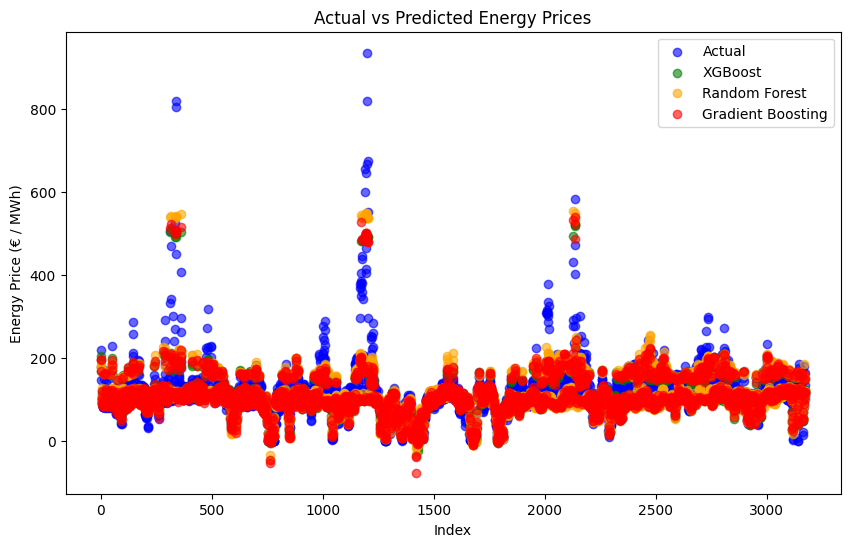

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(range(len(y_test)), y_test, color="blue", label="Actual", alpha=0.6)
plt.scatter(range(len(y_test)), y_pred_xgb, color="green", label="XGBoost", alpha=0.6)
plt.scatter(range(len(y_test)), y_pred_rf, color="orange", label="Random Forest", alpha=0.6)
plt.scatter(range(len(y_test)), y_pred_gb, color="red", label="Gradient Boosting", alpha=0.6)
plt.xlabel("Index")
plt.ylabel("Energy Price (€ / MWh)")
plt.title("Actual vs Predicted Energy Prices")
plt.legend()
plt.show()


# Hyperparameter Tuning

#### Tuning XGBoost (the best model)



In [20]:
# from sklearn.model_selection import GridSearchCV
# from xgboost import XGBRegressor
# from sklearn.metrics import r2_score

# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'max_depth': [3, 5, 7],
#     'min_child_weight': [1, 3, 5],
#     'subsample': [0.7, 0.8, 1.0],
#     'colsample_bytree': [0.7, 0.8, 1.0]
# }
# grid_search = GridSearchCV(
#     estimator=XGBRegressor(random_state=42),
#     param_grid=param_grid,
#     cv=3,
#     scoring='neg_mean_squared_error',
#     verbose=1
# )
# grid_search.fit(X_train, y_train)
# best_xgb_model = grid_search.best_estimator_
# y_pred_best_xgb = best_xgb_model.predict(X_test)
# rmse_best_xgb = np.sqrt(root_mean_squared_error(y_test, y_pred_best_xgb))
# mae_best_xgb = mean_absolute_error(y_test, y_pred_best_xgb)
# test_r2_best_xgb = r2_score(y_test, y_pred_best_xgb)
# print(f"Tuned XGBoost RMSE: {rmse_best_xgb:.4f}")
# print(f"Tuned XGBoost MAE: {mae_best_xgb:.4f}")
# print(f"Tuned XGBoost Test R²: {test_r2_best_xgb:.4f}")

# Evaluation and Refinement

#### Market-Driven Prediction Accuracy
Computing the directional accuracy for XGBoost on the test set

Note: If the direction accuracy is low(<50%), the models might struggle with price trend prediction.

In [21]:
from sklearn.metrics import accuracy_score


# Using the best model (XGBoost) from the timeseriessplit
y_pred_xgb = xgb_model.predict(X_test)

# Random Forest (Predict)
y_pred_rf = rf_model.predict(X_test)

# Gradient Boosting Predictions
y_pred_gb = gb_model.predict(X_test)

# Compute actual and predicted price changes
actual_diff = y_test[1:].values - y_test[:-1].values

pred_diff_xgb = y_pred_xgb[1:] - y_pred_xgb[:-1]
pred_diff_rf = y_pred_rf[1:] - y_pred_rf[:-1]
pred_diff_gb = y_pred_gb[1:] - y_pred_gb[:-1]

# Define directional labels (rise: 1, fall: -1, stable: 0)
threshold = 1.0  # €/MWh
actual_direction = np.where(actual_diff > threshold, 1, np.where(actual_diff < -threshold, -1, 0))

pred_direction_xgb = np.where(pred_diff_xgb > threshold, 1, np.where(pred_diff_xgb < -threshold, -1, 0))
pred_direction_rf = np.where(pred_diff_rf > threshold, 1, np.where(pred_diff_rf < -threshold, -1, 0))
pred_direction_gb = np.where(pred_diff_gb > threshold, 1, np.where(pred_diff_gb < -threshold, -1, 0))

# Calculate directional accuracy
directional_accuracy_xgb = accuracy_score(actual_direction, pred_direction_xgb)
directional_accuracy_rf = accuracy_score(actual_direction, pred_direction_rf)
directional_accuracy_gb = accuracy_score(actual_direction, pred_direction_gb)

# Print results
print(f"Directional Accuracy (XGBoost): {directional_accuracy_xgb:.4f}")
print(f"Directional Accuracy (Random Forest): {directional_accuracy_rf:.4f}")
print(f"Directional Accuracy (Gradient Boosting): {directional_accuracy_gb:.4f}")

Directional Accuracy (XGBoost): 0.6268
Directional Accuracy (Random Forest): 0.5855
Directional Accuracy (Gradient Boosting): 0.6369


### Visualization of the actual vs predicted movement 

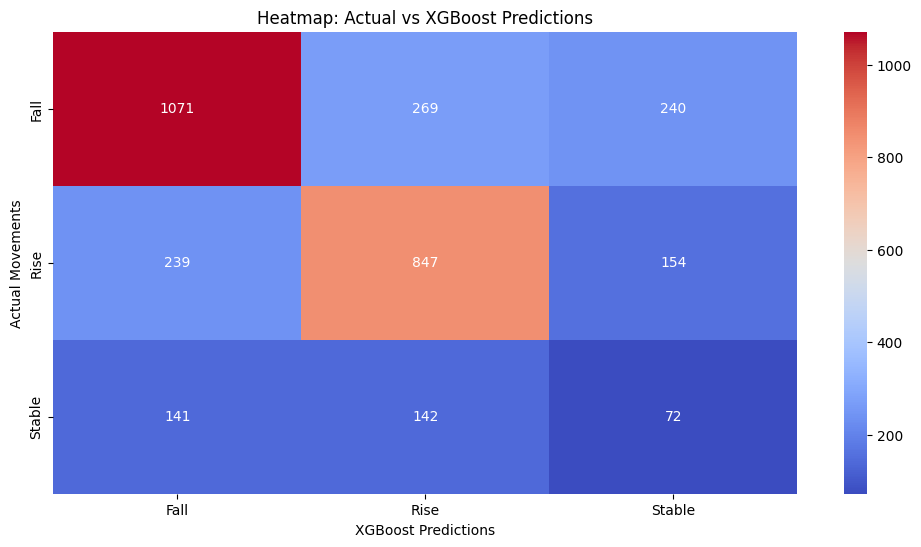

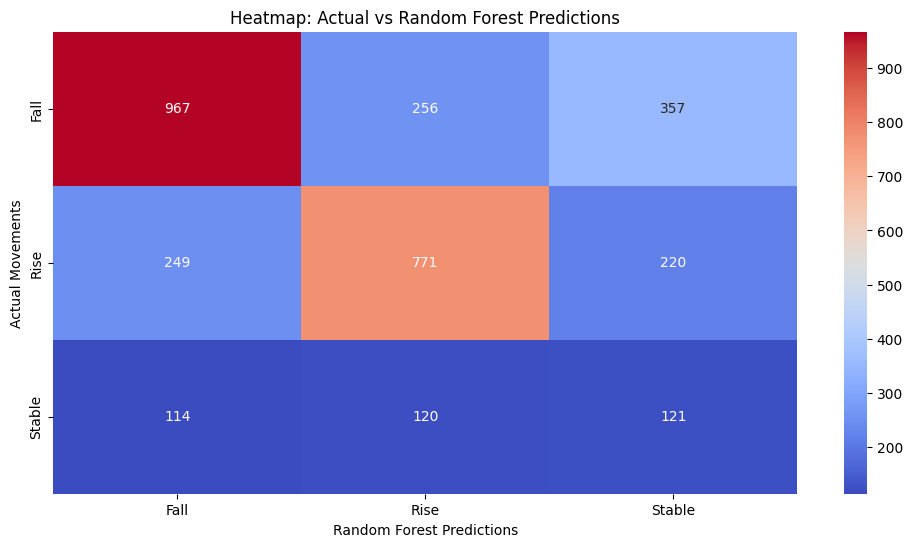

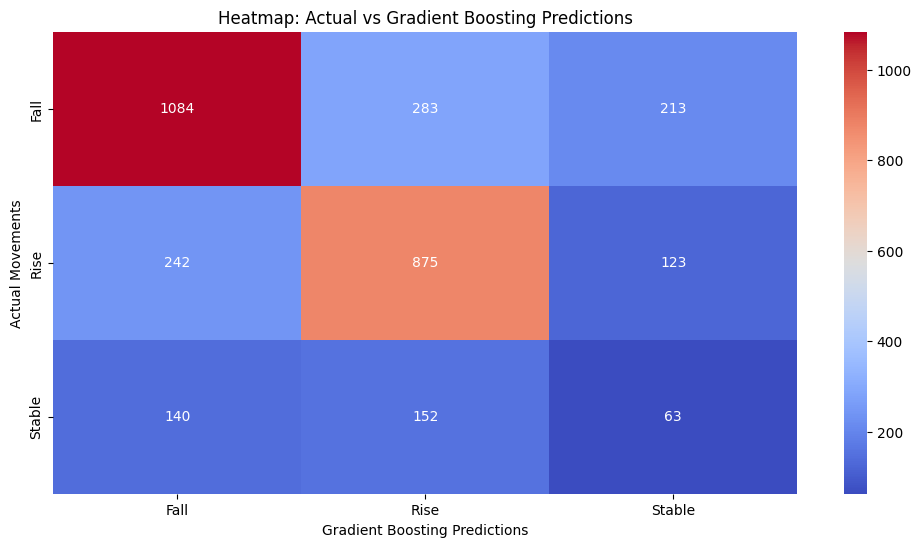

In [22]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Convert values to categorical (for better visualization)
categories = {-1: "Fall", 0: "Stable", 1: "Rise"}
actual_labels = np.vectorize(categories.get)(actual_direction)
xgb_labels = np.vectorize(categories.get)(pred_direction_xgb)
rf_labels = np.vectorize(categories.get)(pred_direction_rf)
gb_labels = np.vectorize(categories.get)(pred_direction_gb)

# Create a dataframe for heatmap
import pandas as pd
df = pd.DataFrame({
    "Actual": actual_labels,
    "XGBoost": xgb_labels,
    "Random Forest": rf_labels,
    "Gradient Boosting": gb_labels
})

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(pd.crosstab(df["Actual"], df["XGBoost"]), cmap="coolwarm", annot=True, fmt="d")
plt.title("Heatmap: Actual vs XGBoost Predictions")
plt.xlabel("XGBoost Predictions")
plt.ylabel("Actual Movements")
plt.show()

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(pd.crosstab(df["Actual"], df["Random Forest"]), cmap="coolwarm", annot=True, fmt="d")
plt.title("Heatmap: Actual vs Random Forest Predictions")
plt.xlabel("Random Forest Predictions")
plt.ylabel("Actual Movements")
plt.show()

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(pd.crosstab(df["Actual"], df["Gradient Boosting"]), cmap="coolwarm", annot=True, fmt="d")
plt.title("Heatmap: Actual vs Gradient Boosting Predictions")
plt.xlabel("Gradient Boosting Predictions")
plt.ylabel("Actual Movements")
plt.show()

<Figure size 600x500 with 0 Axes>

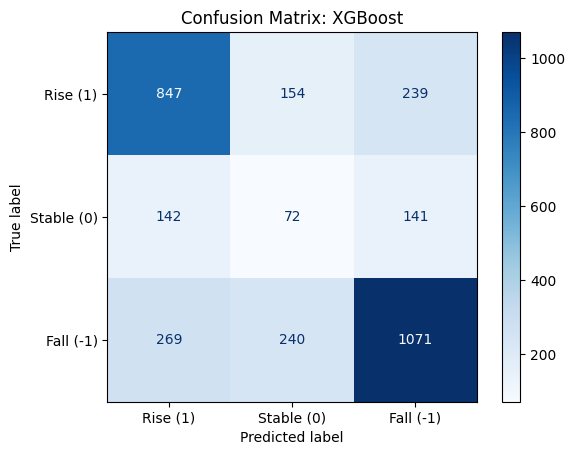

<Figure size 600x500 with 0 Axes>

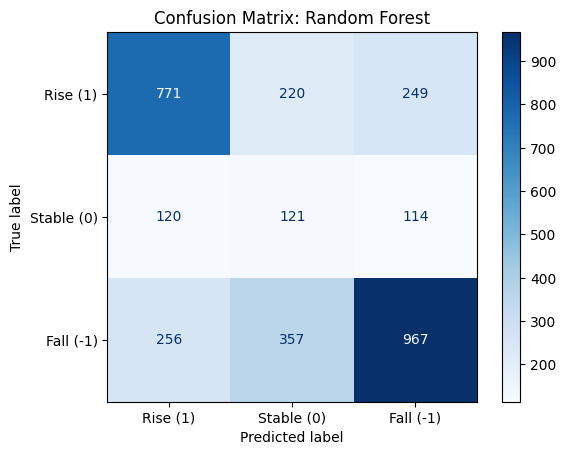

<Figure size 600x500 with 0 Axes>

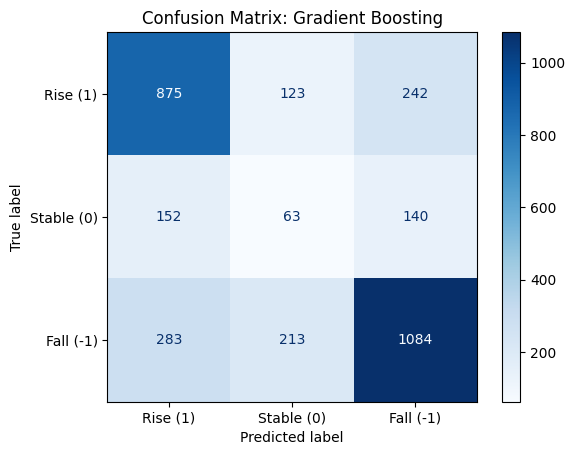

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Define function to plot confusion matrix
def plot_confusion_matrix(actual, predicted, model_name):
    cm = confusion_matrix(actual, predicted, labels=[1, 0, -1])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Rise (1)", "Stable (0)", "Fall (-1)"])
    
    plt.figure(figsize=(6, 5))
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"Confusion Matrix: {model_name}")
    plt.show()

# Plot for each model
plot_confusion_matrix(actual_direction, pred_direction_xgb, "XGBoost")
plot_confusion_matrix(actual_direction, pred_direction_rf, "Random Forest")
plot_confusion_matrix(actual_direction, pred_direction_gb, "Gradient Boosting")


## Volatility Capture

Measure the model’s ability to predict the standard deviation of prices (compare with actual).



In [24]:
# Compute rolling standard deviation (24-hour window)
window = 24
actual_volatility = y_test.rolling(window=window).std().dropna()
pred_volatility = pd.Series(y_pred_xgb, index=y_test.index).rolling(window=window).std().dropna()

# Calculate the correlation between actual and predicted volatility
volatility_correlation = actual_volatility.corr(pred_volatility)

# Calculate the mean absolute error of volatility predictions
volatility_mae = np.mean(np.abs(actual_volatility - pred_volatility))

print(f"Volatility Correlation (XGBoost): {volatility_correlation:.4f}")
print(f"Volatility MAE (XGBoost): {volatility_mae:.4f}")

Volatility Correlation (XGBoost): 0.9263
Volatility MAE (XGBoost): 8.2878


# Business Usability & Interpretability

Since XGBoost is our primary model, i’ll use quantile regression to compute 95% confidence intervals. Quantile regression allows us to predict the lower (2.5th percentile) and upper (97.5th percentile) bounds of the price distribution.



95% Confidence Interval Coverage: 0.9525


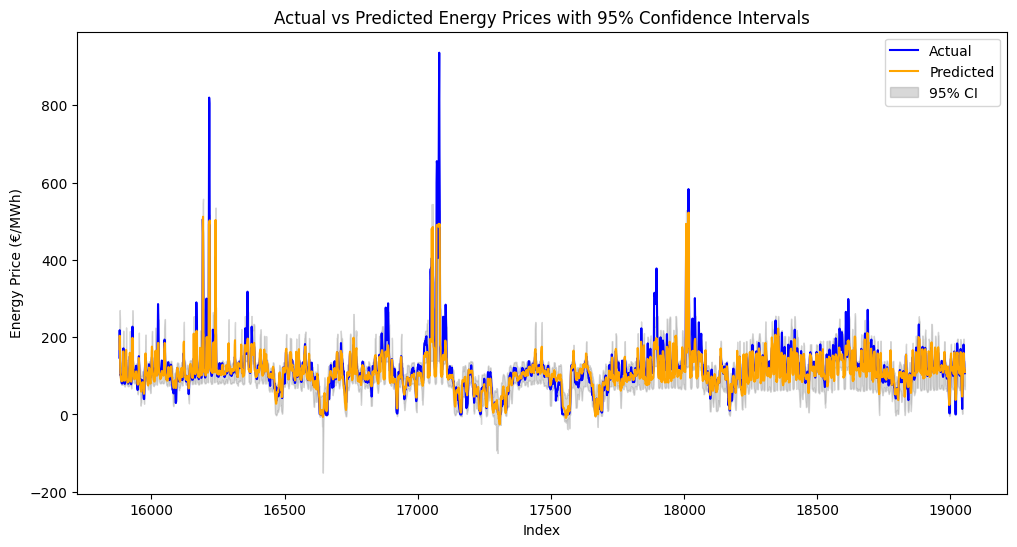

In [25]:
from sklearn.ensemble import GradientBoostingRegressor

# Train models for lower (2.5th percentile) and upper (97.5th percentile) quantiles
lower_quantile = GradientBoostingRegressor(loss='quantile', alpha=0.025, random_state=42)
upper_quantile = GradientBoostingRegressor(loss='quantile', alpha=0.975, random_state=42)

lower_quantile.fit(X_train, y_train)
upper_quantile.fit(X_train, y_train)

# Predict confidence intervals
lower_bound = lower_quantile.predict(X_test)
upper_bound = upper_quantile.predict(X_test)

# Combine with point predictions
y_pred_xgb = xgb_model.predict(X_test)

# Create a DataFrame with predictions and confidence intervals
ci_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_xgb,
    'Lower Bound (2.5%)': lower_bound,
    'Upper Bound (97.5%)': upper_bound
})

# Calculate coverage (percentage of actual values within the confidence interval)
coverage = np.mean((ci_df['Actual'] >= ci_df['Lower Bound (2.5%)']) & (ci_df['Actual'] <= ci_df['Upper Bound (97.5%)']))
print(f"95% Confidence Interval Coverage: {coverage:.4f}")

# Plot confidence intervals
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(ci_df.index, ci_df['Actual'], label='Actual', color='blue')
plt.plot(ci_df.index, ci_df['Predicted'], label='Predicted', color='orange')
plt.fill_between(ci_df.index, ci_df['Lower Bound (2.5%)'], ci_df['Upper Bound (97.5%)'], color='gray', alpha=0.3, label='95% CI')
plt.title('Actual vs Predicted Energy Prices with 95% Confidence Intervals')
plt.xlabel('Index')
plt.ylabel('Energy Price (€/MWh)')
plt.legend()
plt.show()

### Interpretability

Generate SHAP values and feature importance plots

/Users/olaoluwatunmise/Germany-Energy-Price-Forecast/germany-energy/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


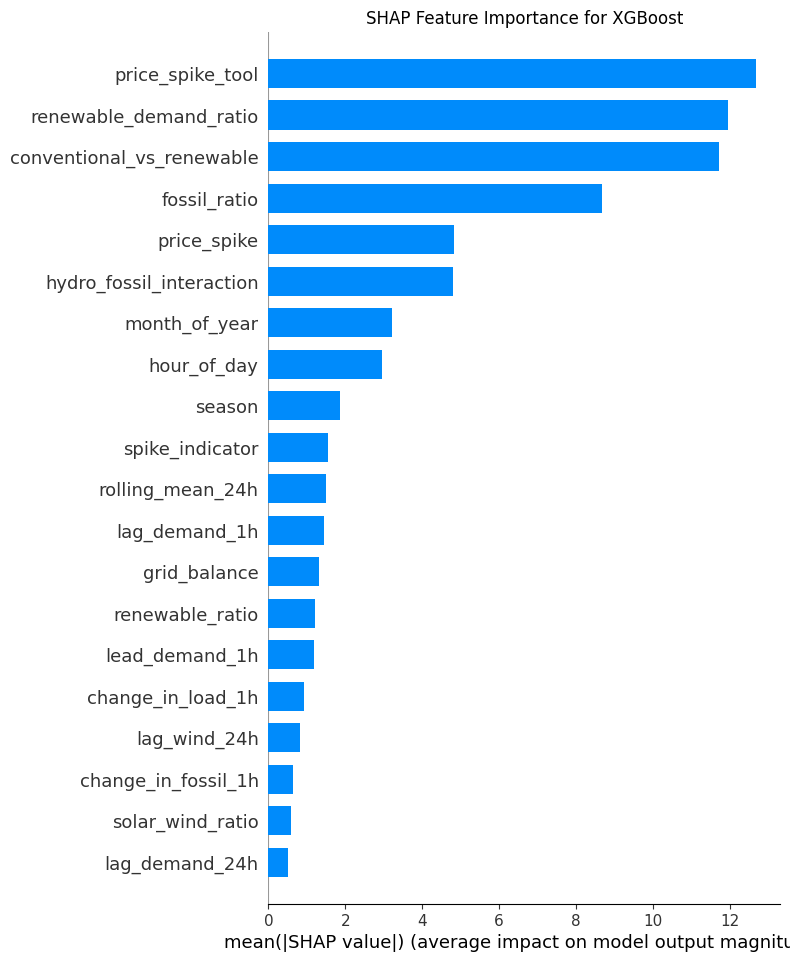

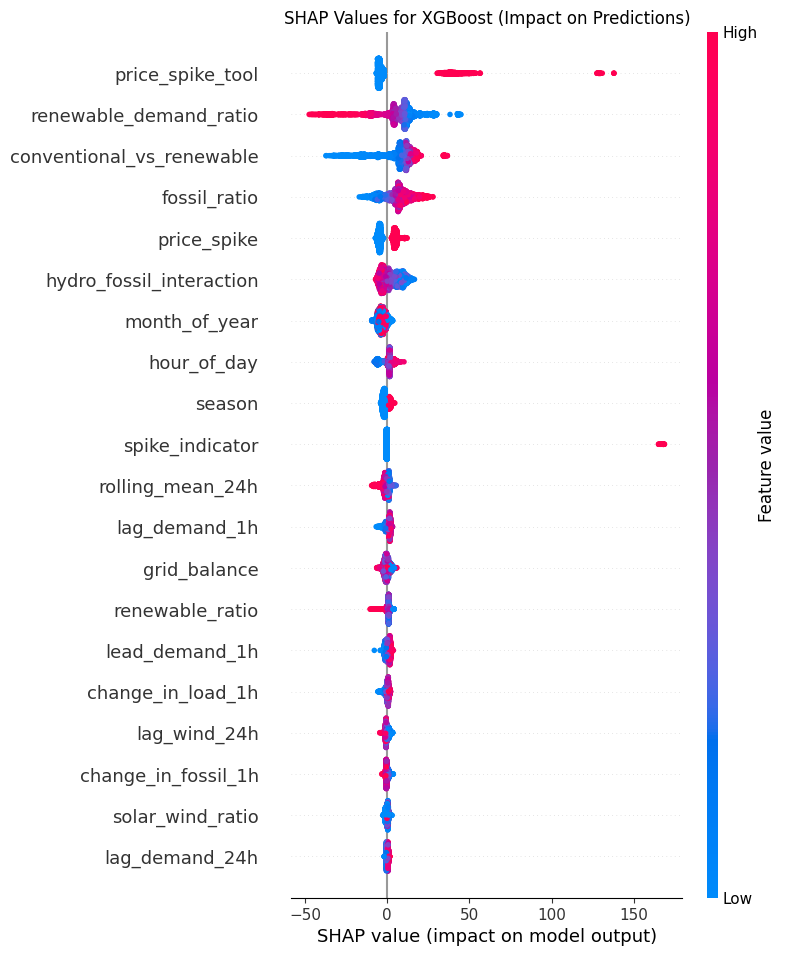

In [26]:
import shap

# Explain predictions using SHAP
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP Feature Importance for XGBoost")
plt.show()

# Detailed SHAP summary plot (impact on predictions)
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Values for XGBoost (Impact on Predictions)")
plt.show()

# Deployment Readiness & Scalability 

In [27]:
from sklearn.metrics import r2_score

# 1-hour ahead predictions are already simulated by the model (using lead_demand_1h)
# Evaluate on the test set (last 20%)
y_pred_xgb = xgb_model.predict(X_test)
rmse_1h = np.sqrt(root_mean_squared_error(y_test, y_pred_xgb))
mae_1h = mean_absolute_error(y_test, y_pred_xgb)
r2_1h = r2_score(y_test, y_pred_xgb)

print("1-Hour Ahead Prediction Performance (XGBoost):")
print(f"RMSE: {rmse_1h:.4f}")
print(f"MAE: {mae_1h:.4f}")
print(f"Test R²: {r2_1h:.4f}")

1-Hour Ahead Prediction Performance (XGBoost):
RMSE: 5.2913
MAE: 16.4117
Test R²: 0.8146


### Ensure Low Latency (<1 sec/prediction) and Scalability



In [28]:
import time

# Measure prediction latency
start_time = time.time()
batch_size = 1000
y_pred_batch = xgb_model.predict(X_test[:batch_size])
end_time = time.time()

latency_per_prediction = (end_time - start_time) / batch_size
print(f"Prediction Latency per Sample: {latency_per_prediction:.6f} seconds")

# Batch processing example (scalable for large datasets)
def predict_in_batches(model, X, batch_size=1000):
    predictions = []
    for i in range(0, len(X), batch_size):
        batch = X[i:i + batch_size]
        batch_pred = model.predict(batch)
        predictions.extend(batch_pred)
    return np.array(predictions)

# Test batch processing
y_pred_full = predict_in_batches(xgb_model, X_test, batch_size=1000)

Prediction Latency per Sample: 0.000003 seconds


# Refinement

### Ensemble Models

Ensemble Models - Created an ensemble of XGBoost and Random Forest (the two best models).



In [29]:
# Ensemble predictions (weighted average of XGBoost and Random Forest)
y_pred_rf = rf_model.predict(X_test)  # Assuming rf_model is trained
ensemble_pred = 0.6 * y_pred_xgb + 0.4 * y_pred_rf  # Weighted average

# Evaluate ensemble
rmse_ensemble = np.sqrt(root_mean_squared_error(y_test, ensemble_pred))
mae_ensemble = mean_absolute_error(y_test, ensemble_pred)
r2_ensemble = r2_score(y_test, ensemble_pred)

print("Ensemble (XGBoost + Random Forest) Performance:")
print(f"RMSE: {rmse_ensemble:.4f}")
print(f"MAE: {mae_ensemble:.4f}")
print(f"Test R²: {r2_ensemble:.4f}")

Ensemble (XGBoost + Random Forest) Performance:
RMSE: 5.2114
MAE: 16.1384
Test R²: 0.8255


### Tune for Extreme Event Detection Using Loss Weighting



In [30]:
from sklearn.metrics import precision_score, recall_score, f1_score
from xgboost import XGBRegressor

# Assign higher weights to extreme events
sample_weights = np.where(y_train > 400, 5.0, 1.0)  # 5x weight for price spikes

# Retrain XGBoost with sample weights
xgb_model_weighted = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model_weighted.fit(X_train, y_train, sample_weight=sample_weights)

# Evaluate on extreme events
y_pred_weighted = xgb_model_weighted.predict(X_test)
actual_extreme = (y_test > 400).astype(int)
pred_extreme_weighted = (y_pred_weighted > 400).astype(int)

precision_weighted = precision_score(actual_extreme, pred_extreme_weighted)
recall_weighted = recall_score(actual_extreme, pred_extreme_weighted)
f1_weighted = f1_score(actual_extreme, pred_extreme_weighted)

print("Extreme Event Detection (Weighted XGBoost):")
print(f"Precision: {precision_weighted:.4f}")
print(f"Recall: {recall_weighted:.4f}")
print(f"F1-Score: {f1_weighted:.4f}")

Extreme Event Detection (Weighted XGBoost):
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000


In [31]:
# Check the number of actual and predicted extreme events
num_actual_extreme = np.sum(actual_extreme)
num_pred_extreme = np.sum(pred_extreme_weighted)
print(f"Number of Actual Extreme Events (y_test > 400): {num_actual_extreme}")
print(f"Number of Predicted Extreme Events (y_pred_weighted > 400): {num_pred_extreme}")

# Check for potential data leakage in features
print("Features used:", selected_features)

# Check a sample of predictions vs. actual values
comparison_df = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred_weighted,
    'Actual Extreme': actual_extreme,
    'Predicted Extreme': pred_extreme_weighted
})
print("\nSample of Predictions vs. Actual Values:")
print(comparison_df.head(10))

Number of Actual Extreme Events (y_test > 400): 27
Number of Predicted Extreme Events (y_pred_weighted > 400): 27
Features used: ['hour_of_day', 'day_of_week', 'is_weekend', 'month_of_year', 'season', 'renewable_ratio', 'fossil_ratio', 'wind_total', 'solar_wind_ratio', 'grid_balance', 'conventional_vs_renewable', 'rolling_mean_24h', 'rolling_std_24h', 'change_in_load_1h', 'change_in_wind_1h', 'change_in_fossil_1h', 'lag_wind_1h', 'lag_wind_24h', 'lag_demand_1h', 'lag_demand_24h', 'lead_demand_1h', 'lead_demand_24h', 'wind_solar_interaction', 'hydro_fossil_interaction', 'renewable_demand_ratio', 'price_spike', 'spike_indicator', 'price_spike_tool', 'seasonality']

Sample of Predictions vs. Actual Values:
       Actual Price  Predicted Price  Actual Extreme  Predicted Extreme
15880        147.15       179.315689               0                  0
15881        218.18       199.174011               0                  0
15882        177.60       199.753830               0                  0